In [1]:

import math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 7
random.seed(seed)
np.random.seed(seed)

settings = {
    # data
    "noise": 0.50,
    "n_obs": 3000,

    # mixture particles
    "M_particles": 20,
    "C_mix": 3,
    "init_edges": 5,
    "min_edges": 3,
    "max_edges": 7,
    "h_init_scale": 0.65,

    # EM / movement
    "n_iter": 1000,
    "graph_warmup": 10,
    "graph_move_every": 5,
    "graph_trials_per_component": 1,
    "move_temp": 0.02,

    # pseudo-likelihood / priors
    "ridge": 1e-3,
    "resid_sigma": 0.50,
    "edge_penalty": 0.015,
    "h_penalty": 1e-4,
    "pi_floor": 1e-3,

    # diagnostics
    "plot_radius": 2,
}
settings


{'noise': 0.5,
 'n_obs': 3000,
 'M_particles': 20,
 'C_mix': 3,
 'init_edges': 5,
 'min_edges': 3,
 'max_edges': 7,
 'h_init_scale': 0.65,
 'n_iter': 1000,
 'graph_warmup': 10,
 'graph_move_every': 5,
 'graph_trials_per_component': 1,
 'move_temp': 0.02,
 'ridge': 0.001,
 'resid_sigma': 0.5,
 'edge_penalty': 0.015,
 'h_penalty': 0.0001,
 'pi_floor': 0.001,
 'plot_radius': 2}

In [2]:

D = 5
EDGE_LIST = [(i, j) for i in range(D) for j in range(D) if i != j]
E = len(EDGE_LIST)
EDGE_INDEX = {e: k for k, e in enumerate(EDGE_LIST)}


def graph_to_vec(G):
    return np.array([G[i, j] for (i, j) in EDGE_LIST], dtype=np.float32)


def vec_to_graph(g):
    G = np.zeros((D, D), dtype=int)
    for val, (i, j) in zip(g, EDGE_LIST):
        G[i, j] = int(val > 0.5)
    return G


def edgevec_to_matrix_np(h):
    H = np.zeros((D, D), dtype=np.float32)
    for val, (i, j) in zip(h, EDGE_LIST):
        H[i, j] = val
    return H


def matrix_to_edgevec_np(H):
    return np.array([H[i, j] for (i, j) in EDGE_LIST], dtype=np.float32)


def is_dag(G):
    G = np.asarray(G).astype(int)
    indeg = G.sum(axis=0).astype(int).tolist()
    queue = [i for i in range(D) if indeg[i] == 0]
    seen = 0
    while queue:
        u = queue.pop()
        seen += 1
        for v in np.where(G[u] == 1)[0]:
            indeg[v] -= 1
            if indeg[v] == 0:
                queue.append(v)
    return seen == D


def topo_order(G):
    G = np.asarray(G).astype(int)
    indeg = G.sum(axis=0).astype(int).tolist()
    queue = [i for i in range(D) if indeg[i] == 0]
    order = []
    while queue:
        u = queue.pop()
        order.append(u)
        for v in np.where(G[u] == 1)[0]:
            indeg[v] -= 1
            if indeg[v] == 0:
                queue.append(v)
    if len(order) != D:
        raise ValueError("not a DAG")
    return order


def graph_dist(A, B):
    return int(np.abs(np.asarray(A).astype(int) - np.asarray(B).astype(int)).sum())


def random_dag_with_edge_count(target_edges=5):
    # sample a random order, then add forward edges in that order
    order = np.random.permutation(D)
    possible = []
    for a in range(D):
        for b in range(a + 1, D):
            possible.append((order[a], order[b]))
    target_edges = min(target_edges, len(possible))
    chosen = np.random.choice(len(possible), size=target_edges, replace=False)
    G = np.zeros((D, D), dtype=int)
    for idx in chosen:
        i, j = possible[int(idx)]
        G[i, j] = 1
    return graph_to_vec(G)


def can_use_graph_vec(g):
    n_edges = int(g.sum())
    if n_edges < settings["min_edges"] or n_edges > settings["max_edges"]:
        return False
    return is_dag(vec_to_graph(g))


def propose_graph_local(g):
    """One local DAG move: add/delete/reverse one edge, respecting edge-count bounds."""
    g = g.astype(np.float32).copy()
    for _ in range(100):
        g2 = g.copy()
        move = np.random.choice(["add", "delete", "reverse"])

        if move == "add":
            zeros = np.where(g2 < 0.5)[0]
            if len(zeros) == 0:
                continue
            e = int(np.random.choice(zeros))
            g2[e] = 1.0

        elif move == "delete":
            ones = np.where(g2 > 0.5)[0]
            if len(ones) == 0:
                continue
            e = int(np.random.choice(ones))
            g2[e] = 0.0

        else:  # reverse
            ones = np.where(g2 > 0.5)[0]
            if len(ones) == 0:
                continue
            e = int(np.random.choice(ones))
            i, j = EDGE_LIST[e]
            rev = EDGE_INDEX[(j, i)]
            g2[e] = 0.0
            g2[rev] = 1.0

        if can_use_graph_vec(g2):
            return g2.astype(np.float32)
    return g


d(G1,G2) = 10
(3000, 5) component counts: [1529 1471]


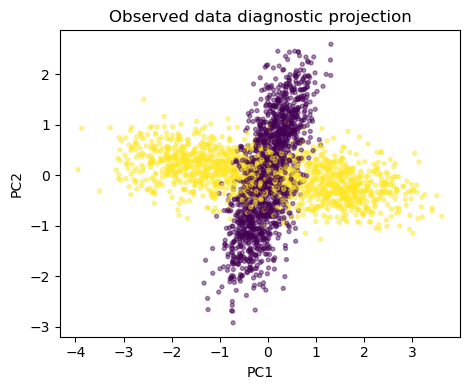

In [3]:

# True data-generating mixture.
G_TRUE_1 = np.zeros((D, D), dtype=int)
for i, j in [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4)]:
    G_TRUE_1[i, j] = 1

G_TRUE_2 = np.zeros((D, D), dtype=int)
for i, j in [(1, 0), (2, 0), (3, 1), (3, 2), (4, 3)]:
    G_TRUE_2[i, j] = 1

H_TRUE_1 = np.zeros((D, D), dtype=np.float32)
H_TRUE_1[0, 1] = 1.25
H_TRUE_1[0, 2] = -1.10
H_TRUE_1[1, 3] = 1.05
H_TRUE_1[2, 3] = 0.90
H_TRUE_1[3, 4] = -1.15

H_TRUE_2 = np.zeros((D, D), dtype=np.float32)
H_TRUE_2[1, 0] = -1.10
H_TRUE_2[2, 0] = 1.20
H_TRUE_2[3, 1] = 1.00
H_TRUE_2[3, 2] = -0.95
H_TRUE_2[4, 3] = 1.15

g_true_1 = graph_to_vec(G_TRUE_1)
g_true_2 = graph_to_vec(G_TRUE_2)
print("d(G1,G2) =", graph_dist(G_TRUE_1, G_TRUE_2))


def simulate_sem_np(G, H, n, noise=0.50):
    G = np.asarray(G).astype(int)
    H = np.asarray(H).astype(np.float32) * G
    X = np.zeros((n, D), dtype=np.float32)
    eps = noise * np.random.randn(n, D).astype(np.float32)
    order = topo_order(G)
    for j in order:
        parents = np.where(G[:, j] == 1)[0]
        if len(parents) == 0:
            X[:, j] = eps[:, j]
        else:
            X[:, j] = np.tanh(X[:, parents]) @ H[parents, j] + eps[:, j]
    return X


def generate_observed_data(n=3000, mix=0.5, noise=0.50):
    z = np.random.binomial(1, mix, size=n)  # diagnostic only
    X = np.zeros((n, D), dtype=np.float32)
    X[z == 0] = simulate_sem_np(G_TRUE_1, H_TRUE_1, int((z == 0).sum()), noise=noise)
    X[z == 1] = simulate_sem_np(G_TRUE_2, H_TRUE_2, int((z == 1).sum()), noise=noise)
    return X, z


X_obs, z_true = generate_observed_data(settings["n_obs"], noise=settings["noise"])
print(X_obs.shape, "component counts:", np.bincount(z_true))

# Quick 2D PCA-style view by SVD, using true labels only for diagnostic color.
Xc = X_obs - X_obs.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
Z2 = Xc @ Vt[:2].T
plt.figure(figsize=(4.8, 4.0))
plt.scatter(Z2[:, 0], Z2[:, 1], c=z_true, s=8, alpha=0.45)
plt.title("Observed data diagnostic projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


In [4]:

def logsumexp_np(A, axis=1):
    m = np.max(A, axis=axis, keepdims=True)
    return np.squeeze(m + np.log(np.sum(np.exp(A - m), axis=axis, keepdims=True) + 1e-12), axis=axis)


def fit_H_given_G_np(X, g, ridge=1e-3, weights=None):
    """Weighted child-wise ridge regression for fixed graph G."""
    G = vec_to_graph(g.astype(int))
    h = np.zeros(E, dtype=np.float32)
    Xfeat = np.tanh(X)

    if weights is None:
        w = np.ones(len(X), dtype=np.float64) / len(X)
    else:
        w = np.asarray(weights, dtype=np.float64)
        w = w / (w.sum() + 1e-12)

    sw = np.sqrt(w)[:, None]
    for j in range(D):
        parents = np.where(G[:, j] == 1)[0]
        if len(parents) == 0:
            continue
        A = Xfeat[:, parents] * sw
        y = X[:, j:j+1] * sw
        lhs = A.T @ A + ridge * np.eye(len(parents))
        rhs = A.T @ y
        beta = np.linalg.solve(lhs, rhs).reshape(-1)
        for p, b in zip(parents, beta):
            h[EDGE_INDEX[(p, j)]] = b
    return h * g


def residual_sum_sq(X, g, h):
    H = edgevec_to_matrix_np(h * g)
    pred = np.tanh(X) @ H
    return ((X - pred) ** 2).sum(axis=1)


def component_loglik(X, g, h, sigma):
    rss = residual_sum_sq(X, g, h)
    return -0.5 * rss / (sigma**2)


def e_step(particle):
    pi = particle["pi"]
    gs = particle["gs"]
    hs = particle["hs"]
    C = len(gs)
    logp = np.column_stack([
        component_loglik(X_obs, gs[c], hs[c], settings["resid_sigma"])
        for c in range(C)
    ])
    log_joint = logp + np.log(pi[None, :] + 1e-12)
    log_norm = logsumexp_np(log_joint, axis=1)
    resp = np.exp(log_joint - log_norm[:, None])
    avg_loglik = float(log_norm.mean())
    return resp, avg_loglik


def score_particle(particle):
    resp, avg_loglik = e_step(particle)
    pi, gs, hs = particle["pi"], particle["gs"], particle["hs"]
    edge_pen = settings["edge_penalty"] * float(sum(pi[c] * gs[c].sum() for c in range(len(gs))))
    h_pen = settings["h_penalty"] * float(sum(pi[c] * np.sum((hs[c] * gs[c]) ** 2) for c in range(len(gs))))
    return avg_loglik - edge_pen - h_pen


def em_update_pi_H(particle):
    resp, _ = e_step(particle)
    C = len(particle["gs"])

    pi = resp.mean(axis=0)
    pi = np.maximum(pi, settings["pi_floor"])
    pi = pi / pi.sum()

    hs = []
    for c in range(C):
        h = fit_H_given_G_np(
            X_obs,
            particle["gs"][c],
            ridge=settings["ridge"],
            weights=resp[:, c],
        )
        hs.append(h.astype(np.float32))

    particle["pi"] = pi.astype(np.float64)
    particle["hs"] = hs
    particle["score"] = score_particle(particle)
    return particle


In [5]:

def init_mixture_particle():
    C = settings["C_mix"]
    pi = np.ones(C, dtype=np.float64) / C
    gs, hs = [], []
    for _ in range(C):
        g = random_dag_with_edge_count(settings["init_edges"])
        h = settings["h_init_scale"] * np.random.randn(E).astype(np.float32) * g
        gs.append(g.astype(np.float32))
        hs.append(h.astype(np.float32))
    p = {"pi": pi, "gs": gs, "hs": hs}
    p["score"] = score_particle(p)
    return p


def copy_particle(p):
    return {
        "pi": p["pi"].copy(),
        "gs": [g.copy() for g in p["gs"]],
        "hs": [h.copy() for h in p["hs"]],
        "score": float(p["score"]),
    }


particles = [init_mixture_particle() for _ in range(settings["M_particles"])]
particles = [em_update_pi_H(p) for p in particles]  # one H/pi calibration before tracking
print("initial best score:", max(p["score"] for p in particles))


initial best score: -3.763012426609217


In [6]:

def try_one_graph_move(particle, c):
    """Propose a local DAG change for component c and accept by mixture score."""
    old = copy_particle(particle)
    old_score = old["score"]

    g_old = old["gs"][c]
    g_new = propose_graph_local(g_old)
    if np.allclose(g_new, g_old):
        return particle, False

    # Fit proposed H using current responsibility for this component.
    resp, _ = e_step(old)
    h_new = fit_H_given_G_np(X_obs, g_new, ridge=settings["ridge"], weights=resp[:, c])

    cand = copy_particle(old)
    cand["gs"][c] = g_new.astype(np.float32)
    cand["hs"][c] = h_new.astype(np.float32)

    # Let pi/H adapt once after the graph move before scoring.
    cand = em_update_pi_H(cand)
    new_score = cand["score"]

    accept_prob = min(1.0, math.exp((new_score - old_score) / max(settings["move_temp"], 1e-12)))
    if new_score >= old_score or np.random.rand() < accept_prob:
        return cand, True
    return old, False


def graph_grid(A_samples, weights=None):
    grid = np.zeros((E + 1, E + 1), dtype=float)
    if weights is None:
        weights = np.ones(len(A_samples), dtype=float) / len(A_samples)
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / (weights.sum() + 1e-12)
    for G, w in zip(A_samples, weights):
        d1 = graph_dist(G, G_TRUE_1)
        d2 = graph_dist(G, G_TRUE_2)
        grid[d2, d1] += float(w)
    return grid


def mode_mass_from_components(particles, radius=2):
    scores = np.array([p["score"] for p in particles], dtype=float)
    pw = np.exp(scores - scores.max())
    pw = pw / (pw.sum() + 1e-12)

    Gs, ws = [], []
    for w, p in zip(pw, particles):
        for pi_c, g in zip(p["pi"], p["gs"]):
            Gs.append(vec_to_graph(g))
            ws.append(float(w * pi_c))

    grid = graph_grid(Gs, ws)
    m1 = grid[:, :radius + 1].sum()
    m2 = grid[:radius + 1, :].sum()
    return float(m1), float(m2), grid


def record_state(it, particles, accepted=0, attempted=0):
    scores = np.array([p["score"] for p in particles], dtype=float)
    best_idx = int(np.argmax(scores))
    m1, m2, grid = mode_mass_from_components(particles, radius=settings["plot_radius"])
    return {
        "iter": it,
        "best_score": float(scores.max()),
        "mean_score": float(scores.mean()),
        "near_G1_mass": m1,
        "near_G2_mass": m2,
        "other_mass": 1 - m1 - m2,
        "accepted": int(accepted),
        "attempted": int(attempted),
        "best_idx": best_idx,
    }, grid


In [7]:

history = []
grid_snapshots = {}
best_comp_history = []

row, grid = record_state(0, particles)
history.append(row)
grid_snapshots[0] = grid.copy()

for it in range(1, settings["n_iter"] + 1):
    # Frequent low-level EM movement: update pi and H every iteration.
    particles = [em_update_pi_H(p) for p in particles]

    accepted = attempted = 0
    if it > settings["graph_warmup"] and it % settings["graph_move_every"] == 0:
        for m in range(len(particles)):
            for c in range(settings["C_mix"]):
                for _ in range(settings["graph_trials_per_component"]):
                    attempted += 1
                    particles[m], acc = try_one_graph_move(particles[m], c)
                    accepted += int(acc)

    row, grid = record_state(it, particles, accepted, attempted)
    history.append(row)

    if it in [settings["graph_warmup"], settings["n_iter"] // 2, settings["n_iter"]]:
        grid_snapshots[it] = grid.copy()

    # Track components of the currently best mixture particle.
    bp = particles[row["best_idx"]]
    for c, (pi_c, g) in enumerate(zip(bp["pi"], bp["gs"])):
        best_comp_history.append({
            "iter": it,
            "component": c,
            "pi": float(pi_c),
            "dist_G1": graph_dist(vec_to_graph(g), G_TRUE_1),
            "dist_G2": graph_dist(vec_to_graph(g), G_TRUE_2),
            "edges": int(g.sum()),
        })

    if it % 10 == 0:
        print(
            f"iter {it:03d} | best {row['best_score']:.3f} | "
            f"near G1 {row['near_G1_mass']:.3f} | near G2 {row['near_G2_mass']:.3f} | "
            f"graph accept {accepted}/{attempted}"
        )

hist = pd.DataFrame(history)
comp_hist = pd.DataFrame(best_comp_history)
display(hist.tail())


iter 010 | best -3.589 | near G1 0.000 | near G2 0.000 | graph accept 0/0
iter 020 | best -3.517 | near G1 0.000 | near G2 0.000 | graph accept 31/60
iter 030 | best -3.435 | near G1 0.016 | near G2 0.000 | graph accept 42/60
iter 040 | best -3.323 | near G1 0.015 | near G2 0.000 | graph accept 32/60
iter 050 | best -3.328 | near G1 0.000 | near G2 0.000 | graph accept 35/60
iter 060 | best -3.317 | near G1 0.000 | near G2 0.000 | graph accept 32/60
iter 070 | best -3.298 | near G1 0.000 | near G2 0.000 | graph accept 32/60
iter 080 | best -3.275 | near G1 0.000 | near G2 0.000 | graph accept 29/60
iter 090 | best -3.266 | near G1 0.022 | near G2 0.000 | graph accept 28/60
iter 100 | best -3.264 | near G1 0.023 | near G2 0.000 | graph accept 27/60
iter 110 | best -3.259 | near G1 0.056 | near G2 0.000 | graph accept 24/60
iter 120 | best -3.195 | near G1 0.112 | near G2 0.029 | graph accept 29/60
iter 130 | best -3.179 | near G1 0.114 | near G2 0.030 | graph accept 25/60
iter 140 | bes

,iter,best_score,mean_score,near_G1_mass,near_G2_mass,other_mass,accepted,attempted,best_idx
996,996,-3.060413,-3.113214,0.418452,0.399247,0.182301,0,0,7
997,997,-3.060413,-3.113141,0.418462,0.399248,0.182290,0,0,7
998,998,-3.060413,-3.113096,0.418467,0.399247,0.182286,0,0,7
999,999,-3.060412,-3.113063,0.418468,0.399241,0.182290,0,0,7
1000,1000,-3.060422,-3.114385,0.419201,0.399554,0.181245,25,60,7


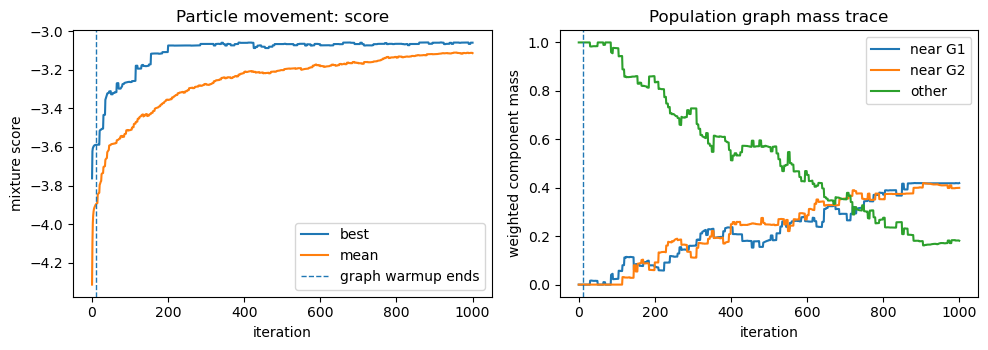

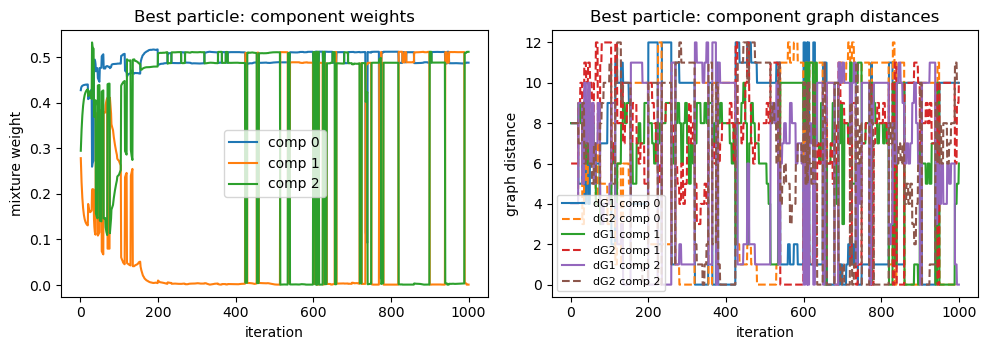

In [8]:

# Movement traces.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(hist["iter"], hist["best_score"], label="best")
axes[0].plot(hist["iter"], hist["mean_score"], label="mean")
axes[0].axvline(settings["graph_warmup"], ls="--", lw=1, label="graph warmup ends")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("mixture score")
axes[0].set_title("Particle movement: score")
axes[0].legend()

axes[1].plot(hist["iter"], hist["near_G1_mass"], label="near G1")
axes[1].plot(hist["iter"], hist["near_G2_mass"], label="near G2")
axes[1].plot(hist["iter"], hist["other_mass"], label="other")
axes[1].axvline(settings["graph_warmup"], ls="--", lw=1)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("weighted component mass")
axes[1].set_title("Population graph mass trace")
axes[1].legend()
plt.tight_layout()
plt.show()

# Best particle component traces.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for c in sorted(comp_hist["component"].unique()):
    sub = comp_hist[comp_hist["component"] == c]
    axes[0].plot(sub["iter"], sub["pi"], label=f"comp {c}")
    axes[1].plot(sub["iter"], sub["dist_G1"], label=f"dG1 comp {c}")
    axes[1].plot(sub["iter"], sub["dist_G2"], ls="--", label=f"dG2 comp {c}")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("mixture weight")
axes[0].set_title("Best particle: component weights")
axes[0].legend()
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("graph distance")
axes[1].set_title("Best particle: component graph distances")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


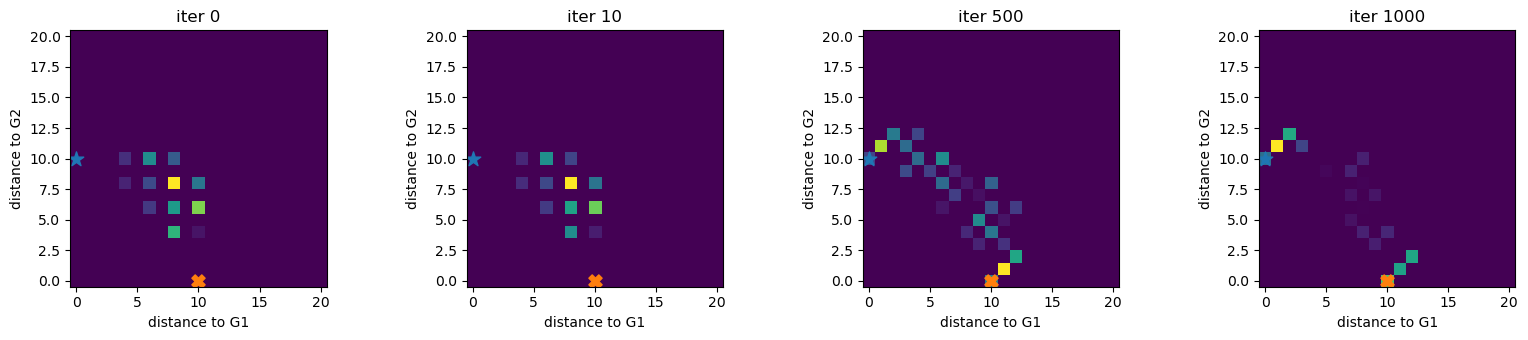

In [9]:

def plot_grid(grid, ax, title, radius=2):
    d12 = graph_dist(G_TRUE_1, G_TRUE_2)
    im = ax.imshow(grid, origin="lower", aspect="equal")
    ax.scatter([0], [d12], marker="*", s=120, label="G1")
    ax.scatter([d12], [0], marker="X", s=90, label="G2")
    ax.set_xlabel("distance to G1")
    ax.set_ylabel("distance to G2")
    ax.set_title(title)
    return im

keys = sorted(grid_snapshots.keys())
fig, axes = plt.subplots(1, len(keys), figsize=(4.0 * len(keys), 3.5))
if len(keys) == 1:
    axes = [axes]
for ax, k in zip(axes, keys):
    plot_grid(grid_snapshots[k], ax, f"iter {k}", radius=settings["plot_radius"])
plt.tight_layout()
plt.show()


In [10]:

# Final best particle summary.
scores = np.array([p["score"] for p in particles])
best = particles[int(np.argmax(scores))]
rows = []
for c, (pi_c, g, h) in enumerate(zip(best["pi"], best["gs"], best["hs"])):
    G = vec_to_graph(g)
    rows.append({
        "component": c,
        "pi": float(pi_c),
        "edges": int(g.sum()),
        "dist_G1": graph_dist(G, G_TRUE_1),
        "dist_G2": graph_dist(G, G_TRUE_2),
        "H_norm": float(np.sqrt(np.sum((h * g) ** 2))),
    })
summary_df = pd.DataFrame(rows)
print("best final score:", float(best["score"]))
display(summary_df)


best final score: -3.0604222396117624


,component,pi,edges,dist_G1,dist_G2,H_norm
0,0,0.487596,5,10,0,2.407213
1,1,0.001000,5,6,10,2.937646
2,2,0.511404,5,0,10,2.418362



## Notes

This notebook intentionally moves \(H,\pi\) every iteration and moves \(G\) only after warmup and every few iterations.

Reason: \(H,\pi\) should adapt to the current graph before testing a discrete graph mutation. If \(G\) moves as often as \(H\), the acceptance score is noisy and components can jump before their mechanisms/responsibilities stabilize.
